# Preprocessing

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from torch.utils.data import WeightedRandomSampler

### Resize

In [2]:
input_dataset = 'dataset'
output_dataset = 'dataset_224x224'

categories = sorted([c for c in os.listdir(input_dataset) if os.path.isdir(os.path.join(input_dataset, c))])

for category in tqdm(categories):
    for split in ['train', 'test']:
        split_path = os.path.join(input_dataset, category, split)
        for subfolder in os.listdir(split_path):
            input_path = os.path.join(split_path, subfolder)
            output_path = os.path.join(output_dataset, category, split, subfolder)
            os.makedirs(output_path, exist_ok=True)
            for filename in os.listdir(input_path):
                image = Image.open(os.path.join(input_path, filename)).convert("RGB")
                image = image.resize((224, 224))
                image.save(os.path.join(output_path, filename))

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [04:03<00:00, 16.26s/it]


In [3]:
dataset = 'dataset_224x224'
categories = sorted([c for c in os.listdir(dataset) if os.path.isdir(os.path.join(dataset, c))])
print(f"Categories: {categories}")

Categories: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


### Dataset Summary

In [4]:
print(f"{'Category':15} | {'Train good':10} | {'Test good':9} | {'Test defect':11} | {'Total':6}")
print("-" * 60)

total_train = 0
total_test_good = 0
total_test_defect = 0

for category in categories:
    train_good = os.path.join(dataset, category, "train", "good")
    test_path = os.path.join(dataset, category, "test")
    
    num_train = len(os.listdir(train_good))
    num_test_good = 0
    num_test_defect = 0
    
    for subfolder in os.listdir(test_path):
        full_path = os.path.join(test_path, subfolder)
        if subfolder == "good":
            num_test_good += len(os.listdir(full_path))
        else:
            num_test_defect += len(os.listdir(full_path))
    
    total = num_train + num_test_good + num_test_defect
    total_train += num_train
    total_test_good += num_test_good
    total_test_defect += num_test_defect
    
    print(f"{category:15} | {num_train:10} | {num_test_good:9} | {num_test_defect:11} | {total:6}")

print("-" * 60)
print(f"{'TOTAL':15} | {total_train:10} | {total_test_good:9} | {total_test_defect:11} | {total_train+total_test_good+total_test_defect:6}")

Category        | Train good | Test good | Test defect | Total 
------------------------------------------------------------
bottle          |        209 |        20 |          63 |    292
cable           |        224 |        58 |          92 |    374
capsule         |        219 |        23 |         109 |    351
carpet          |        280 |        28 |          89 |    397
grid            |        264 |        21 |          57 |    342
hazelnut        |        391 |        40 |          70 |    501
leather         |        245 |        32 |          92 |    369
metal_nut       |        220 |        22 |          93 |    335
pill            |        267 |        26 |         141 |    434
screw           |        320 |        41 |         119 |    480
tile            |        230 |        33 |          84 |    347
toothbrush      |         60 |        12 |          30 |    102
transistor      |        213 |        60 |          40 |    313
wood            |        247 |        19 | 

### Good vs Defect Examples

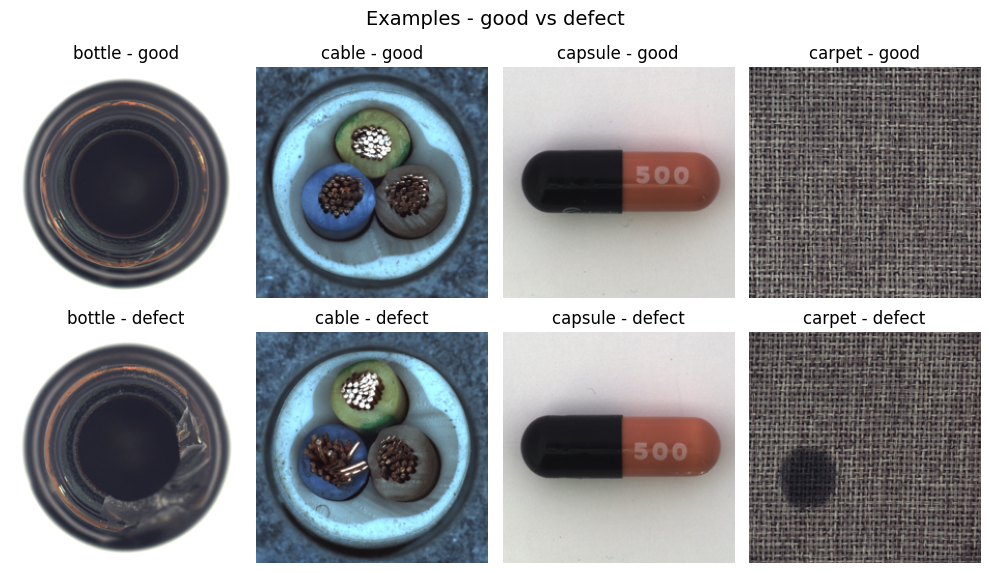

In [5]:
displayed_categories = categories[:4]
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("Examples - good vs defect", fontsize=14)

for i, category in enumerate(displayed_categories):
    test_path = os.path.join(dataset, category, "test")
    
    good_path = os.path.join(test_path, "good")
    image = Image.open(os.path.join(good_path, os.listdir(good_path)[0]))
    axes[0, i].imshow(image)
    axes[0, i].set_title(f"{category} - good")
    axes[0, i].axis("off")
    
    defect_folder = [f for f in os.listdir(test_path) if f != "good"][0]
    defect_path = os.path.join(test_path, defect_folder)
    image = Image.open(os.path.join(defect_path, os.listdir(defect_path)[0]))
    axes[1, i].imshow(image)
    axes[1, i].set_title(f"{category} - defect")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### Dataset class

In [6]:
class MVTecDataset(Dataset):
    def __init__(self, dataset_path, transform=None, mode="train"):
        super().__init__()
        self.transform = transform
        self.data = []
        
        categories = sorted([c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))])
        
        for category in categories:
            if mode == "train":
                good_path = os.path.join(dataset_path, category, "train", "good")
                for filename in os.listdir(good_path):
                    self.data.append((os.path.join(good_path, filename), 0))
                
                test_path = os.path.join(dataset_path, category, "test")
                for subfolder in os.listdir(test_path):
                    if subfolder != "good":
                        full_path = os.path.join(test_path, subfolder)
                        images = os.listdir(full_path)
                        train_split = int(len(images) * 0.7)
                        for filename in images[:train_split]:
                            self.data.append((os.path.join(full_path, filename), 1))
            
            elif mode == "test":
                test_path = os.path.join(dataset_path, category, "test")
                for subfolder in os.listdir(test_path):
                    full_path = os.path.join(test_path, subfolder)
                    images = os.listdir(full_path)
                    if subfolder == "good":
                        for filename in images:
                            self.data.append((os.path.join(full_path, filename), 0))
                    else:
                        test_split = int(len(images) * 0.7)
                        for filename in images[test_split:]:
                            self.data.append((os.path.join(full_path, filename), 1))
        
        np.random.shuffle(self.data)
        print(f"[{mode}] Total images: {len(self.data)}")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        path, label = self.data[index]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

### Transform, DataLoader and verification

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = MVTecDataset(dataset, transform=transform, mode="train")
test_dataset = MVTecDataset(dataset, transform=transform, mode="test")

labels = [l for _, l in train_dataset.data]
print(f"Train - good: {labels.count(0)}, defect: {labels.count(1)}")

weights = torch.DoubleTensor([1.0/labels.count(0) if l == 0 else 1.0/labels.count(1) for l in labels])
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

images, labels = next(iter(train_dataloader))
print(f"Batch shape: {images.shape}")

[train] Total images: 4478
[test] Total images: 876
Train - good: 3629, defect: 849
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
Batch shape: torch.Size([128, 3, 224, 224])
